## Importing libraries and modules

In [59]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score , root_mean_squared_error , mean_squared_error , mean_absolute_percentage_error


## Data fetchings and Data information

In [60]:
data = pd.read_csv('Salary_Data.csv')

print(data.info())
print("--------------------------------")
print("\n\nThe shape of the data is : ",data.shape)
print("--------------------------------")
print("\n\nThe description of the data is as: \n\n",data.describe())
print("--------------------------------")
print("\n\nNull values in the data are: \n\n",data.isnull().sum())
print("\n\n--------------------------------")

data.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes
None
--------------------------------


The shape of the data is :  (30, 2)
--------------------------------


The description of the data is as: 

        YearsExperience         Salary
count        30.000000      30.000000
mean          5.313333   76003.000000
std           2.837888   27414.429785
min           1.100000   37731.000000
25%           3.200000   56720.750000
50%           4.700000   65237.000000
75%           7.700000  100544.750000
max          10.500000  122391.000000
--------------------------------


Null values in the data are: 

 YearsExperience    0
Salary             0
dtype: int64


--------------------------------


,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


## EDA using seaborn

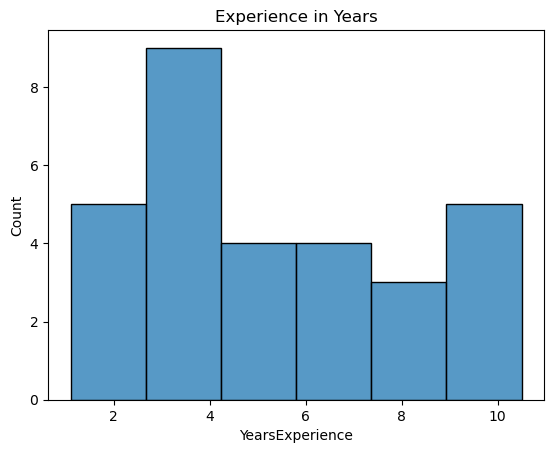

In [61]:
sns.histplot(data['YearsExperience'])
plt.title("Experience in Years")
plt.savefig('Graphs/salary_dist.png')
plt.show()

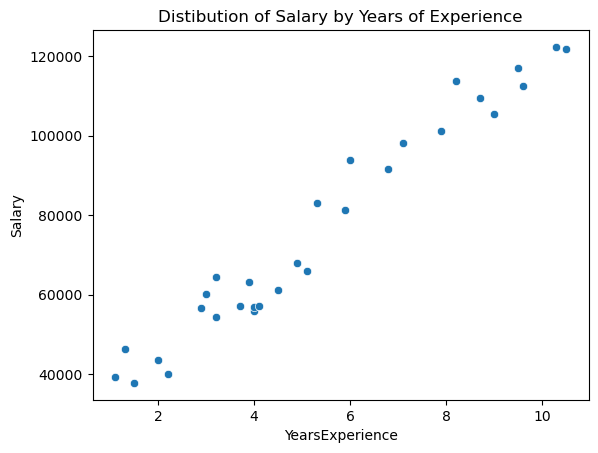

In [62]:
sns.scatterplot(data=data , x = data['YearsExperience'] , y = data['Salary'])
plt.title("Distibution of Salary by Years of Experience")
plt.savefig('Graphs/scatter_salary.png')
plt.show()

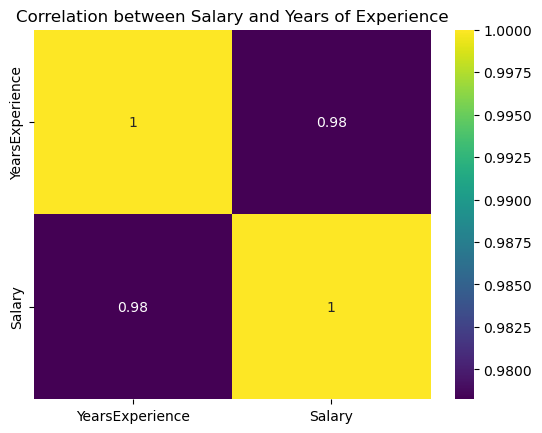

In [63]:
## We can also find the correlation and map it to the heatmap to analyse the correlatiion visually
corr = data.corr()

sns.heatmap(data = corr , annot= True , cmap='viridis')
plt.title("Correlation between Salary and Years of Experience")
plt.savefig('Graphs/correlation_salary.png')
plt.show()

## Model Building 

In [64]:
X = data['YearsExperience'].values.reshape(-1,1)
y = data['Salary'].values.reshape(-1,1)

In [65]:
## Fitting the data points to the model 

regressor = LinearRegression()
regressor.fit(X.round(0),y)

LinearRegression()

In [66]:
## Predictions 
y_pred = regressor.predict(X)

y_pred

array([[ 36916.73898447],
       [ 38777.98950902],
       [ 40639.24003357],
       [ 45292.36634494],
       [ 47153.61686949],
       [ 53667.99370541],
       [ 54598.61896769],
       [ 56459.86949224],
       [ 56459.86949224],
       [ 61112.99580361],
       [ 62974.24632816],
       [ 63904.87159043],
       [ 63904.87159043],
       [ 64835.49685271],
       [ 68557.9979018 ],
       [ 72280.4989509 ],
       [ 74141.74947545],
       [ 76003.        ],
       [ 81586.75157365],
       [ 82517.37683592],
       [ 89962.37893412],
       [ 92754.25472094],
       [100199.25681914],
       [102991.13260596],
       [107644.25891733],
       [110436.13470415],
       [115089.26101553],
       [116019.8862778 ],
       [122534.26311372],
       [124395.51363827]])

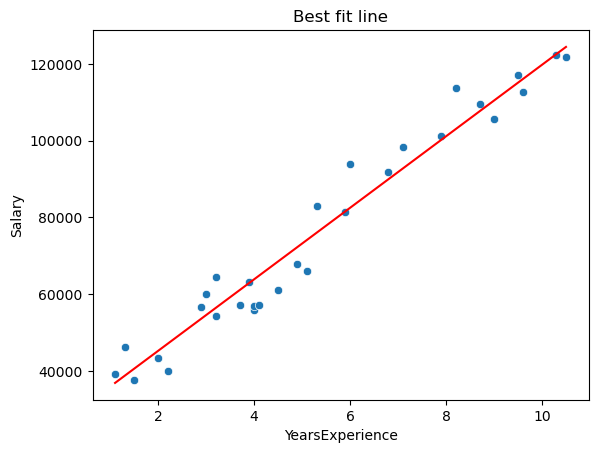

In [67]:
sns.scatterplot(data=data , x = data['YearsExperience'] , y = data['Salary'])
plt.plot(X, y_pred , color = 'red' )
plt.title("Best fit line")
plt.savefig('Graphs/scatter_best_fit.png')
plt.show()

## Model Evaluation

In [68]:
from math import sqrt

score = r2_score(y,y_pred)
error = sqrt(mean_squared_error(y,y_pred))
error1 = mean_absolute_percentage_error(y,y_pred)
print(f"The score of the model is {score:.2f} ")
print(f"The Root mean square value is {error: .2f}")
print(f"The percentage error is {error1*100: .2f}")

The score of the model is 0.96 
The Root mean square value is  5607.77
The percentage error is  7.11
